# Exploratory Data Analysis — NASA C-MAPSS

The C-MAPSS dataset simulates turbofan engine degradation. Each engine runs from a healthy state until failure, with 21 sensors recording things like temperatures, pressures, and fan speeds at every cycle.

The job is to predict **Remaining Useful Life (RUL)** — how many cycles does an engine have left?

Before touching any model, I need to understand the data properly:
- What does a degradation trajectory actually look like?
- Which sensors carry useful signal, and which are just noise?
- How do we turn raw trajectories into training windows?

I'll work with **FD001** throughout the EDA. It's the simplest subset — single operating condition, single fault mode (high-pressure compressor degradation). Good place to build intuition.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
### Column names aren't in the files, so we define them manually.
### 3 operational settings + 21 sensors, plus unit and cycle identifiers.
col_names = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]
train = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=col_names)
test  = pd.read_csv('../data/raw/test_FD001.txt',  sep='\s+', header=None, names=col_names)

print(train.shape, test.shape)
train.head()

(20631, 26) (13096, 26)


,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## A quick look at the structure

20,631 rows in training — that's not 20,631 engines, that's the total number of cycles across all engines combined. Each engine (identified by `unit`) has its own trajectory of varying length.

First thing I need to do is compute the **true RUL** for every row in the training set. Since training trajectories run all the way to failure, the RUL at any cycle is simply:

`RUL = max_cycle_for_that_engine - current_cycle`

I'll also apply **RUL clipping** at 125 cycles. Early in an engine's life, the degradation signal is basically flat — the engine isn't showing any signs of wear yet. Predicting "312 cycles remaining" vs "289 cycles remaining" from clean sensor readings is meaningless.

In [3]:
### compute max cycle per engine, then RUL = max_cycle - current_cycle
max_cycles = train.groupby('unit')['cycle'].max()
train = train.merge(max_cycles.rename('max_cycle'), on='unit')
train['rul'] = train['max_cycle'] - train['cycle']

### clip RUL at 125 — anything beyond this is "healthy enough, we don't care exactly how healthy"
RUL_CLIP = 125
train['rul'] = train['rul'].clip(upper=RUL_CLIP)

train[['unit', 'cycle', 'max_cycle', 'rul']].head(10)

,unit,cycle,max_cycle,rul
0,1,1,192,125
1,1,2,192,125
2,1,3,192,125
3,1,4,192,125
4,1,5,192,125
5,1,6,192,125
6,1,7,192,125
7,1,8,192,125
8,1,9,192,125
9,1,10,192,125


## How long do engines actually live?

Before I build any windows or models, it's worth just looking at the distribution of engine lifespans. This tells us whether our training set has enough diversity — a mix of short-lived and long-lived engines — and helps us think about what "hard" predictions look like (very short trajectories leave the model little history to work with).

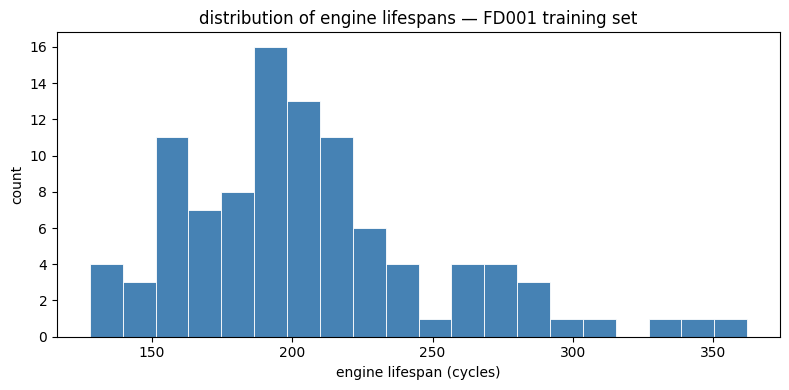

engines: 100
shortest: 128 cycles,  longest: 362 cycles,  median: 199 cycles


In [4]:
lifespans = train.groupby('unit')['max_cycle'].first()

plt.figure(figsize=(8, 4))
plt.hist(lifespans, bins=20, color='steelblue', edgecolor='white', linewidth=0.6)
plt.xlabel('engine lifespan (cycles)')
plt.ylabel('count')
plt.title('distribution of engine lifespans — FD001 training set')
plt.tight_layout()
plt.show()

print(f"engines: {len(lifespans)}")
print(f"shortest: {lifespans.min()} cycles,  longest: {lifespans.max()} cycles,  median: {lifespans.median():.0f} cycles")

## Which sensors actually carry signal?

We have 21 sensors, but not all of them are useful. Some are essentially constant throughout an engine's life — they record the same value cycle after cycle, which means they carry zero information about degradation.

We'll measure this two ways:
1. **Standard deviation across the entire training set** — near-zero std means the sensor barely moves
2. **Visual inspection** — plot every sensor averaged across all engines to see which ones trend as the engine degrades

The sensors we drop aren't broken or wrong — they just don't vary with degradation in this operating condition. FD001 has a single fixed operating condition, so some sensors that *would* vary across operating conditions are constant here.

In [5]:
sensor_cols = [f's{i}' for i in range(1, 22)]

### std of each sensor across the whole training set
sensor_stds = train[sensor_cols].std()

print("sensor standard deviations:")
print(sensor_stds.round(4).to_string())

sensor standard deviations:
s1      0.0000
s2      0.5001
s3      6.1311
s4      9.0006
s5      0.0000
s6      0.0014
s7      0.8851
s8      0.0710
s9     22.0829
s10     0.0000
s11     0.2671
s12     0.7376
s13     0.0719
s14    19.0762
s15     0.0375
s16     0.0000
s17     1.5488
s18     0.0000
s19     0.0000
s20     0.1807
s21     0.1083


## Visualising degradation trends

For each sensor, I want to see: does its average value change as engines approach failure?

To make engines comparable, we align them by **cycles remaining** (i.e., from the end), bin those into 20 evenly spaced windows, and average. If a sensor shows a clear trend in this view, it's informative. If it's flat, it's not.

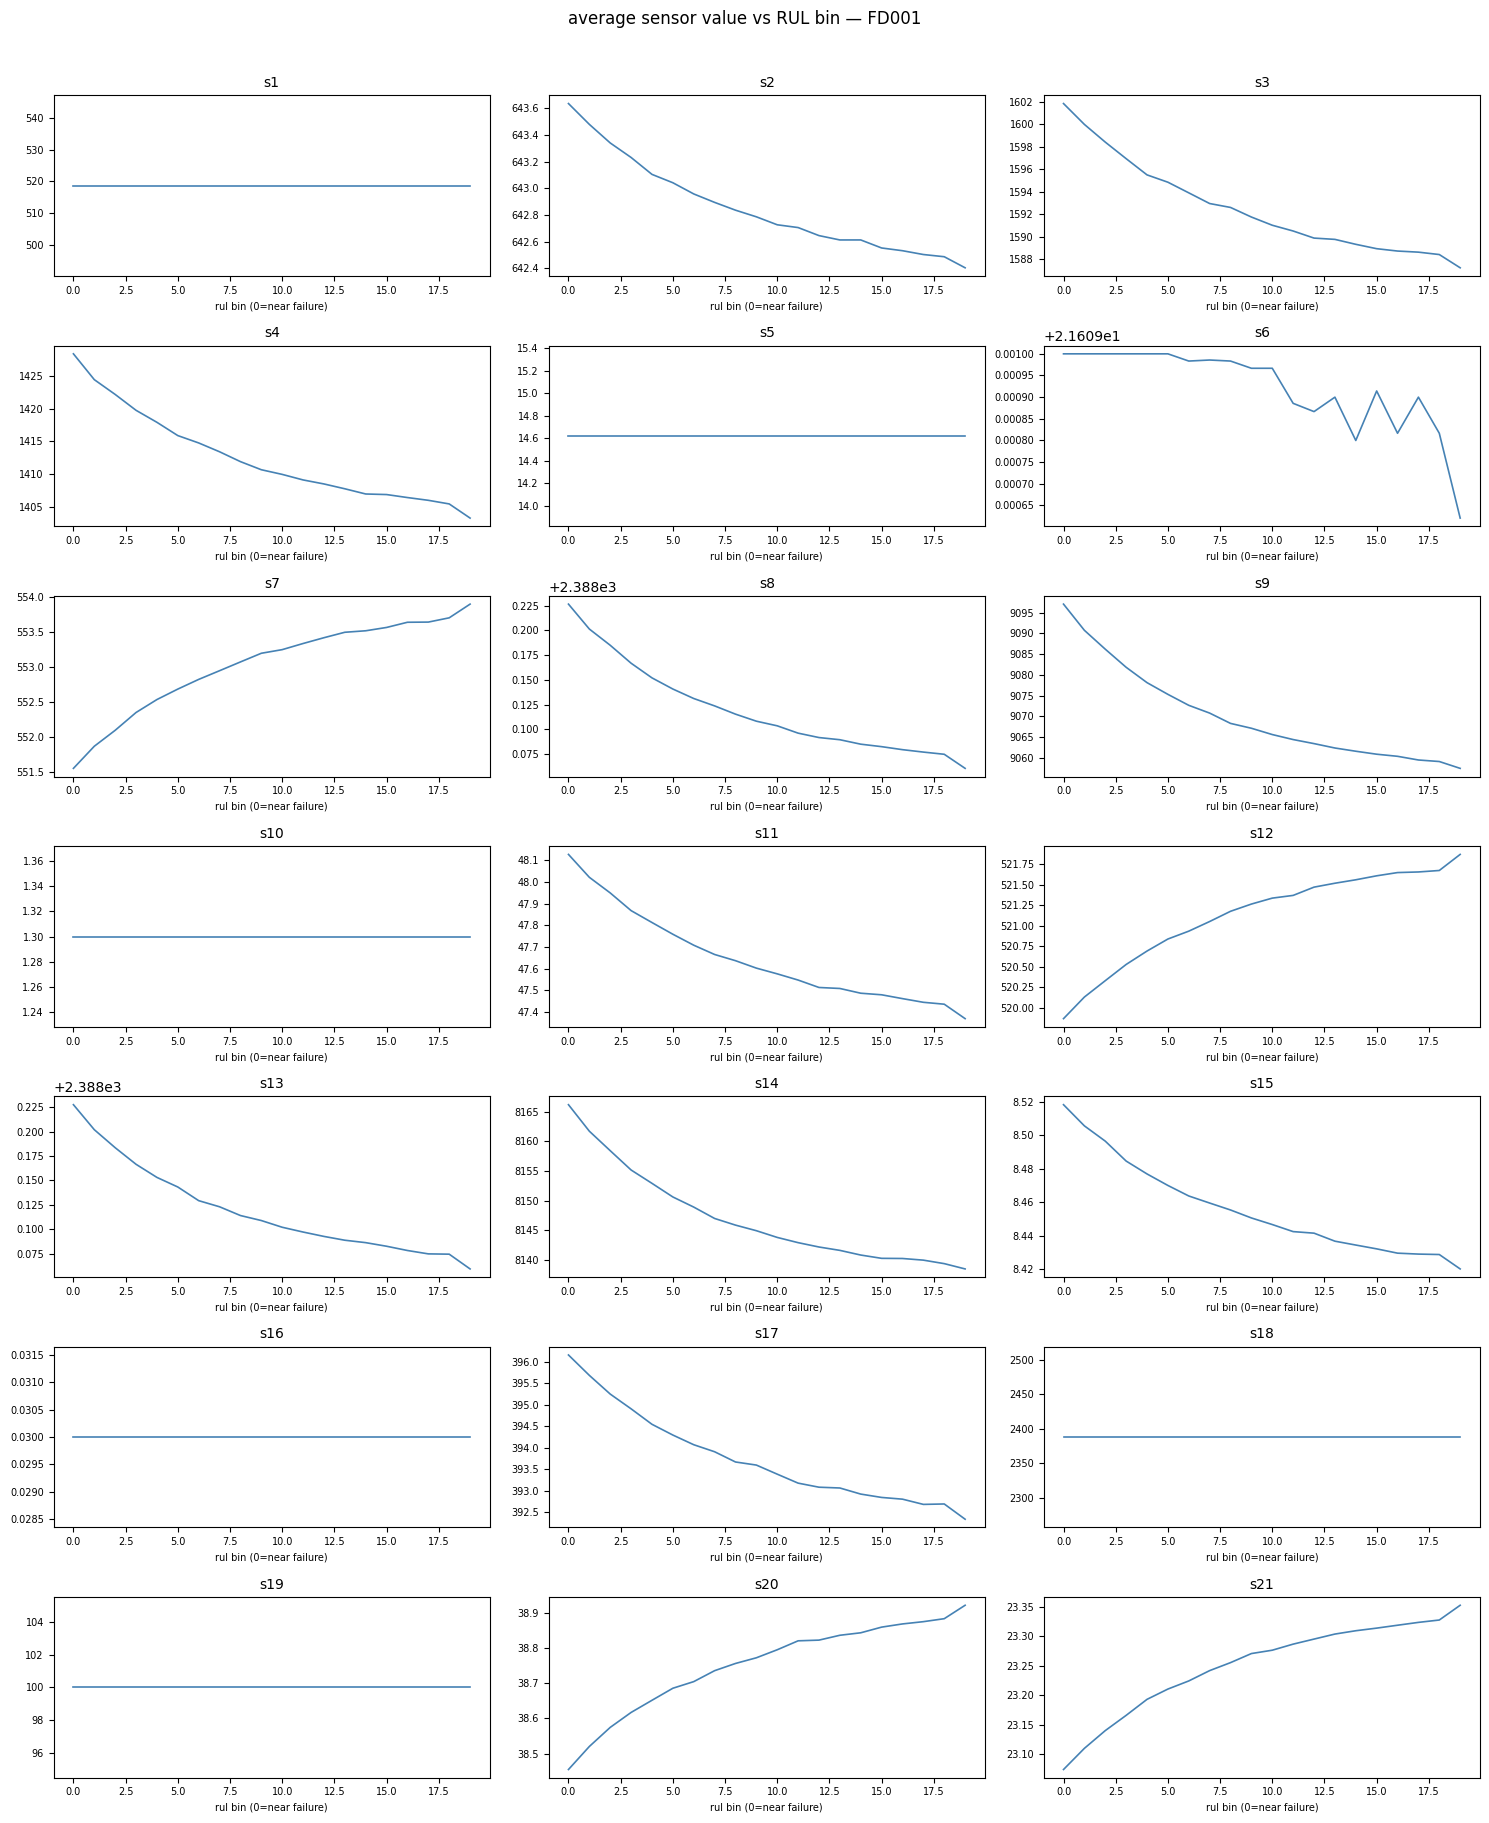

In [6]:
sensor_cols = [f's{i}' for i in range(1, 22)]

### bin cycles-remaining into 20 equal buckets so all engines are on the same x-axis
train['rul_bin'] = pd.cut(train['rul'], bins=20, labels=False)
sensor_trend = train.groupby('rul_bin')[sensor_cols].mean()

fig, axes = plt.subplots(7, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].plot(sensor_trend.index, sensor_trend[col], color='steelblue', linewidth=1.2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('rul bin (0=near failure)', fontsize=7)
    axes[i].tick_params(labelsize=7)

### turn off the two empty subplots at the end
for j in range(len(sensor_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('average sensor value vs RUL bin — FD001', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## Dropping uninformative sensors

Based on standard deviation and visual inspection, 7 sensors are essentially constant throughout FD001 — they record the same value regardless of where the engine is in its lifecycle. These carry zero degradation signal and would just add noise to the input.

I also drop the 3 operational settings — in FD001, the operating condition is fixed, so these are constant columns too.

What I am left with is **14 sensors**, all showing clear monotonic trends as engines approach failure. These are my features going forward.

In [7]:
### sensors with zero or near-zero variance — confirmed flat in the trend plots
drop_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

### operational settings are constant in FD001 (single operating condition)
drop_ops = ['os1', 'os2', 'os3']

feature_cols = [c for c in sensor_cols if c not in drop_sensors]

print("dropped:", drop_sensors + drop_ops)
print("kept features:", feature_cols)
print("feature count:", len(feature_cols))

dropped: ['s1', 's5', 's6', 's10', 's16', 's18', 's19', 'os1', 'os2', 'os3']
kept features: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
feature count: 14


## Looking at individual degradation trajectories

The trend plots above averaged across all 100 engines — useful for spotting signal, but it hides the engine-to-engine variability. Looking at a handful of individual trajectories for a couple of the most informative sensors.

This matters because the models will be trained on individual engine histories, not averages. If there's high variability between engines, that's something the model needs to handle.

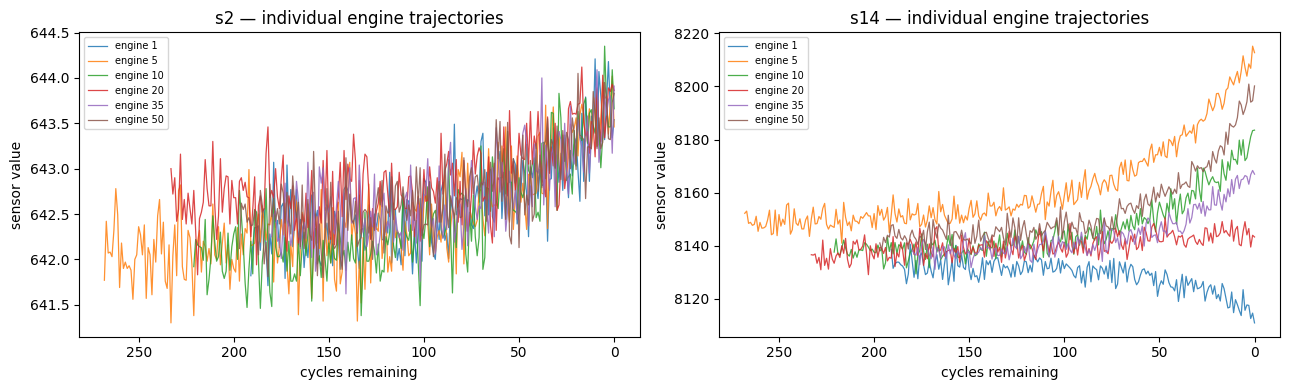

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sample_units = [1, 5, 10, 20, 35, 50]
colors = plt.cm.tab10.colors

for i, unit_id in enumerate(sample_units):
    eng = train[train['unit'] == unit_id].copy()
    ### x-axis: cycles remaining so all engines end at 0
    x = eng['max_cycle'] - eng['cycle']
    axes[0].plot(x, eng['s2'],  color=colors[i], linewidth=0.9, label=f'engine {unit_id}', alpha=0.85)
    axes[1].plot(x, eng['s14'], color=colors[i], linewidth=0.9, label=f'engine {unit_id}', alpha=0.85)

for ax, sensor in zip(axes, ['s2', 's14']):
    ax.set_xlabel('cycles remaining')
    ax.set_ylabel('sensor value')
    ax.set_title(f'{sensor} — individual engine trajectories')
    ax.invert_xaxis()
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Normalization

Before feeding data to any model, we normalize each sensor to zero mean and unit variance. I compute statistics **only on the training set** and apply them to both train and test — standard practice to avoid data leakage.

I also normalize the operational settings even though they're constant in FD001, just so the pipeline generalizes cleanly when I apply it to FD002–FD004 later.

In [9]:
from sklearn.preprocessing import StandardScaler

all_feature_cols = feature_cols  ### 14 sensors, ops already excluded

scaler = StandardScaler()
scaler.fit(train[all_feature_cols])

train_scaled = train.copy()
train_scaled[all_feature_cols] = scaler.transform(train[all_feature_cols])

### quick sanity check — post-normalization mean and std should be ~0 and ~1
means = train_scaled[all_feature_cols].mean().round(4)
stds  = train_scaled[all_feature_cols].std().round(4)
print("post-normalization means (should all be ~0):")
print(means.to_string())
print("\npost-normalization stds (should all be ~1):")
print(stds.to_string())

post-normalization means (should all be ~0):
s2     0.0
s3    -0.0
s4     0.0
s7    -0.0
s8     0.0
s9    -0.0
s11   -0.0
s12    0.0
s13    0.0
s14   -0.0
s15    0.0
s17    0.0
s20    0.0
s21    0.0

post-normalization stds (should all be ~1):
s2     1.0
s3     1.0
s4     1.0
s7     1.0
s8     1.0
s9     1.0
s11    1.0
s12    1.0
s13    1.0
s14    1.0
s15    1.0
s17    1.0
s20    1.0
s21    1.0


## The sliding window approach

Ican't feed a whole engine trajectory into a model at once — trajectories have different lengths, and at test time we only see a truncated history anyway.

The standard approach is a **sliding window**: take the last W cycles of sensor readings as input, predict the RUL at the final cycle of that window. 

I'll use **W = 30 cycles** — enough history to smooth out the noise we saw in individual trajectories, while still being short enough that even the shortest engine (128 cycles) gives me many training samples.

A quick illustration of what one training sample looks like:
- Input shape: `(30, 14)` — 30 timesteps, 14 sensor features
- Target: a single RUL value (the clipped RUL at the last cycle of the window)

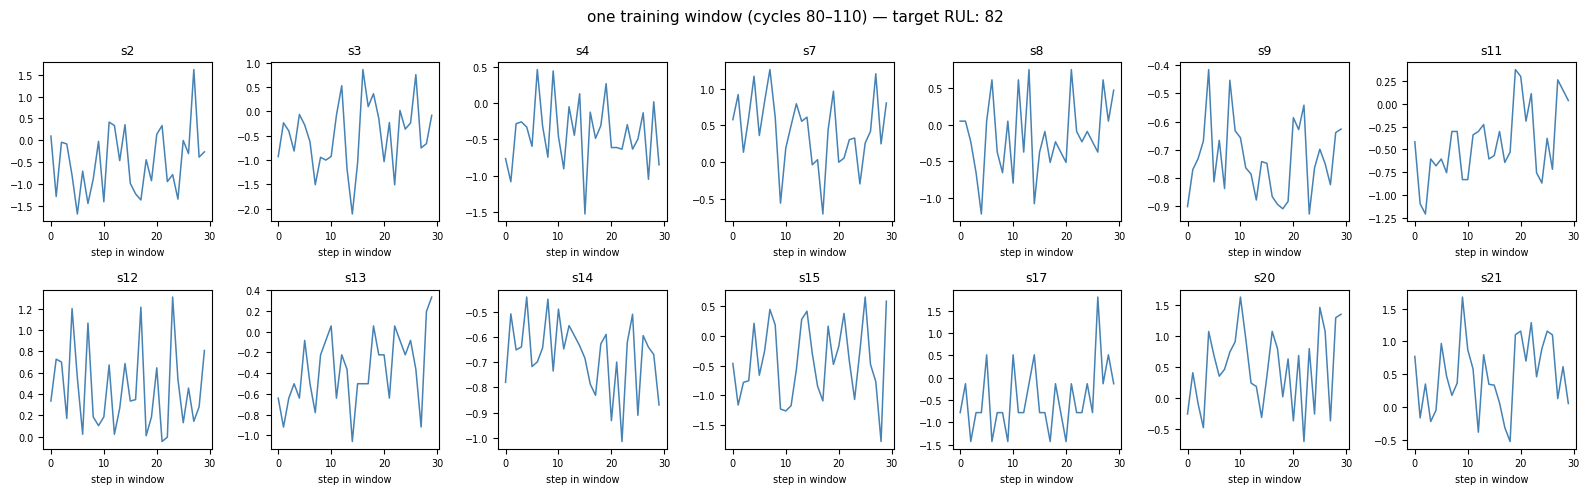

In [10]:
### grab one engine and show what a single 30-cycle window looks like
WINDOW_SIZE = 30
eng1 = train_scaled[train_scaled['unit'] == 1].reset_index(drop=True)

### take a window from the middle of the trajectory — cycle 80 to 110
window_start = 80
window = eng1.iloc[window_start : window_start + WINDOW_SIZE]
target_rul = eng1.iloc[window_start + WINDOW_SIZE - 1]['rul']

fig, axes = plt.subplots(2, 7, figsize=(16, 5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].plot(range(WINDOW_SIZE), window[col].values, color='steelblue', linewidth=1.1)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('step in window', fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle(f'one training window (cycles {window_start}–{window_start+WINDOW_SIZE}) — target RUL: {int(target_rul)}', 
             fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
import pickle, os

os.makedirs('../checkpoints', exist_ok=True)

### save scaler so every subsequent notebook uses identical normalization
with open('../checkpoints/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

### save feature list so we never hardcode it again anywhere
with open('../checkpoints/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("saved scaler and feature list to checkpoints/")
print("features:", feature_cols)
print("window size we'll use:", WINDOW_SIZE)

saved scaler and feature list to checkpoints/
features: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
window size we'll use: 30
